In [1]:
import json
import os
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import torch as t
import seaborn as sns
import sys
from scipy.stats import hypergeom
from pprint import pprint

sys.path.insert(0, '..')
from evaluate_circuit import get_edge_list, get_node_list
from config_act_patch import dim_layer_pos_dict, dim_layer_map

In [2]:
model_dims_dict = {
    'google/gemma-2-2b-it': 2304,
    'meta-llama/Llama-3.2-3B-Instruct': 3072,
    'Qwen/Qwen3-8B': 4096
}

In [3]:
nonsparse_paths = {
    'google/gemma-2-2b-it': {
        'dim': 'layer15_pos-1',
        'ntp': 'ntp_bsz6_lr1e-2_seed42',
        'reps': 'reps_bsz6_lr1e-2_ss2e-2_seed5'
    },
    'meta-llama/Llama-3.2-3B-Instruct': {
        'dim': 'layer12_pos-4',
        'ntp': 'ntp_bsz12_lr1e-2_seed5',
        'reps': 'reps_bsz12_lr1e-2_ss1e-5_seed5'
    },
    'Qwen/Qwen3-8B': {
        'dim': 'layer20_pos-8',
    },
}

g2_model_path = 'google/gemma-2-2b-it'
g2_model_dims = model_dims_dict[g2_model_path]
l3_model_path = 'meta-llama/Llama-3.2-3B-Instruct'
l3_model_dims = model_dims_dict[l3_model_path]
q8_model_path = 'Qwen/Qwen3-8B'
q8_model_dims = model_dims_dict[q8_model_path]

In [4]:
# get dim results
def get_sparse_results(thresh_type, vals, exp_name, model_path):
    results = []
    vector_dir = f"../pipeline/runs/{model_path.split('/')[-1]}/"
    layer, pos = dim_layer_pos_dict[model_path][dim_layer_map[model_path]]

    for r in vals:
        if r == 0:
            if 'dim' in exp_name:
                completions_dir = f"completions_{nonsparse_paths[model_path]['dim']}"
            if 'ntp' in exp_name:
                completions_dir = f"completions_{nonsparse_paths[model_path]['ntp']}"
            if 'reps' in exp_name:
                completions_dir = f"completions_{nonsparse_paths[model_path]['reps']}"
        else:
            completions_dir = f'completions_{exp_name}_{thresh_type}={r}'
        # alpaca
        with open(os.path.join(vector_dir, completions_dir, 'harmless_actadd_evaluations.json'), 'r') as f:
            data = json.load(f)
        a_asr = data["substring_matching_success_rate"]

        # jailbreakbench
        with open(os.path.join(vector_dir, completions_dir, 'jailbreakbench_actadd_evaluations.json'), 'r') as f:
            data = json.load(f)
        jbb_asr = data["llamaguard2_success_rate"]

        # strongreject
        with open(os.path.join(vector_dir, completions_dir, 'strongreject_actadd_evaluations.json'), 'r') as f:
            data = json.load(f)
        sr_asr = data["llamaguard2_success_rate"]
        results.append((a_asr, jbb_asr, sr_asr))

    return results



In [6]:
def get_avg_results(*results_lists):
    """
    Takes any number of results lists (each from get_sparse_results).
    Each results list is [(a_asr, jbb_asr, sr_asr), ...] with n entries.
    Averages and computes std element-wise across the results lists.
    Returns (avg_results, std_results), each a list of (a_asr, jbb_asr, sr_asr) tuples.
    """
    import numpy as np
    n = len(results_lists[0])
    avg_results = []
    std_results = []
    for i in range(n):
        a_vals   = np.array([r[i][0] for r in results_lists])
        jbb_vals = np.array([r[i][1] for r in results_lists])
        sr_vals  = np.array([r[i][2] for r in results_lists])
        avg_results.append((a_vals.mean(), jbb_vals.mean(), sr_vals.mean()))
        std_results.append((a_vals.std(), jbb_vals.std(), sr_vals.std()))
    return avg_results, std_results


In [7]:
def get_sim(v1, v2):
    return t.cosine_similarity(v1, v2, dim=0)

def get_iou(v1, v2):
    intersection = t.logical_and(v1, v2).sum()
    union = t.logical_or(v1, v2).sum()
    return intersection / union

### visualize Qwen 3 8B sparsity for openreview

In [5]:
q8_dim_dropouts = [0,516,1492,2296,3595,3974,4071,4090]
rtols = [0,0.1,0.3,0.5,1,1.5,2,2.5]
dim_rtol_results = get_sparse_results('rtol', rtols, 'dim_logit', q8_model_path)
dim_dropout_results = get_sparse_results('dropout', q8_dim_dropouts, 'dim_logit', q8_model_path)
dim_mag_results = get_sparse_results('mag', q8_dim_dropouts, 'dim_logit', q8_model_path)
dim_ie_results = get_sparse_results('ie', q8_dim_dropouts, 'dim_logit', q8_model_path)
xs = [n/q8_model_dims for n in q8_dim_dropouts]
print(len(dim_rtol_results))
print(xs)

8
[0.0, 0.1259765625, 0.3642578125, 0.560546875, 0.877685546875, 0.97021484375, 0.993896484375, 0.99853515625]


In [7]:
# format is alpaca, jbb, strong reject tuples, at increasing sparsities
print(dim_rtol_results)
print(dim_dropout_results)
print(dim_mag_results)
print(dim_ie_results)

[(0.015, 0.83, 0.8881789137380192), (0.005, 0.89, 0.9201277955271565), (0.0, 0.84, 0.8913738019169329), (0.01, 0.82, 0.8945686900958466), (0.0, 0.8, 0.8626198083067093), (0.195, 0.73, 0.7827476038338658), (0.96, 0.49, 0.5463258785942492), (0.96, 0.27, 0.4281150159744409)]
[(0.015, 0.83, 0.8881789137380192), (0.015, 0.82, 0.9009584664536742), (0.035, 0.85, 0.8785942492012779), (0.12, 0.77, 0.8146964856230032), (0.95, 0.5, 0.5591054313099042), (0.98, 0.15, 0.15654952076677317), (0.99, 0.13, 0.16293929712460065), (1.0, 0.04, 0.03514376996805112)]
[(0.015, 0.83, 0.8881789137380192), (0.01, 0.83, 0.8913738019169329), (0.005, 0.86, 0.9041533546325878), (0.015, 0.84, 0.8785942492012779), (0.075, 0.78, 0.8562300319488818), (0.43, 0.59, 0.6900958466453674), (0.885, 0.47, 0.4984025559105431), (0.975, 0.4, 0.4440894568690096)]
[(0.015, 0.83, 0.8881789137380192), (0.01, 0.83, 0.9041533546325878), (0.0, 0.87, 0.9169329073482428), (0.005, 0.85, 0.9009584664536742), (0.015, 0.8, 0.8562300319488818), 

[0.0, 0.1259765625, 0.3642578125, 0.560546875, 0.877685546875, 0.97021484375, 0.993896484375, 0.99853515625]
[0.015, 0.005, 0.0, 0.01, 0.0, 0.195, 0.96, 0.96]
[0.83, 0.89, 0.84, 0.82, 0.8, 0.73, 0.49, 0.27]
[0.8881789137380192, 0.9201277955271565, 0.8913738019169329, 0.8945686900958466, 0.8626198083067093, 0.7827476038338658, 0.5463258785942492, 0.4281150159744409]


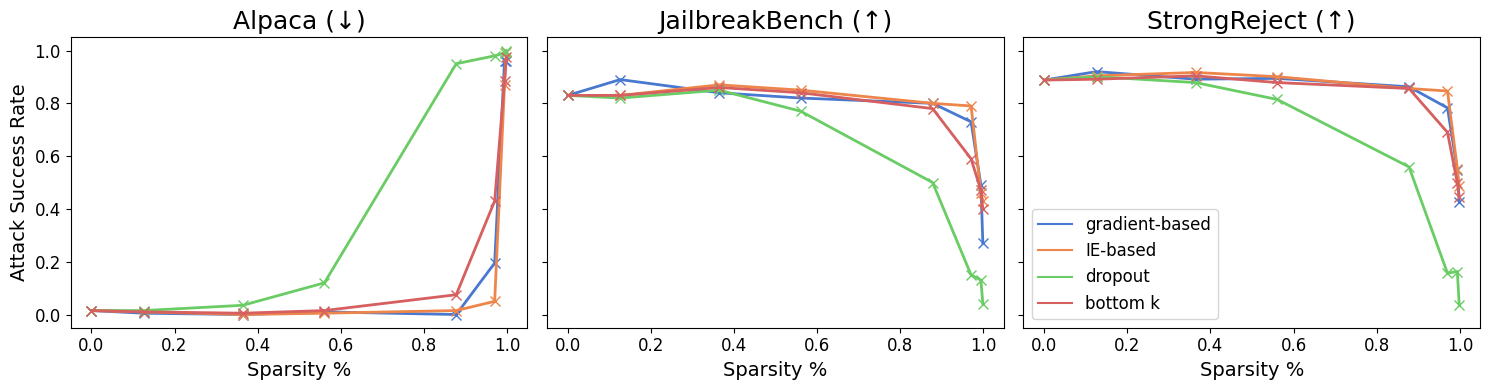

In [24]:
datasets   = ['Alpaca (↓)', 'JailbreakBench (↑)', 'StrongReject (↑)']
ds_indices = [0, 1, 2]

# each results list is [(a_asr, jbb_asr, sr_asr), ...] with 6 entries
xs = [n/q8_model_dims for n in q8_dim_dropouts]
palette = sns.color_palette("muted", 4)

print(xs)
x_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, ds_name, ds_idx in zip(axes, datasets, ds_indices):
    rtol_vals    = [r[ds_idx] for r in dim_rtol_results]
    dropout_vals = [r[ds_idx] for r in dim_dropout_results]
    mag_vals     = [r[ds_idx] for r in dim_mag_results]
    ie_vals     = [r[ds_idx] for r in dim_ie_results]
    print(rtol_vals)

    ax.plot(xs, rtol_vals, color=palette[0],  linestyle='-', marker='x', markersize=7, linewidth=2,   label=f'gradient-based')
    ax.plot(xs, ie_vals, color=palette[1], linestyle='-', marker='x', markersize=7, linewidth=2, label=f'IE-based')
    ax.plot(xs, dropout_vals, color=palette[2], linestyle='-', marker='x', markersize=7, linewidth=2, label=f'dropout')
    ax.plot(xs, mag_vals, color=palette[3], linestyle='-', marker='x', markersize=7, linewidth=2, label=f'bottom k')

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticks, fontsize=12)
    ax.set_xlabel('Sparsity %', fontsize=14)
    ax.set_title(ds_name, fontsize=18)

axes[0].tick_params('y', labelsize=12)
axes[0].set_ylabel('Attack Success Rate', fontsize=14)

# build legend with one entry per method (solid) + one for dropout style
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=palette[0], linewidth=1.5, linestyle="-", label="gradient-based"),
    Line2D([0], [0], color=palette[1], linewidth=1.5, linestyle="-", label="IE-based"),
    Line2D([0], [0], color=palette[2], linewidth=1.5, linestyle="-", label="dropout"),
    Line2D([0], [0], color=palette[3], linewidth=1.5, linestyle="-", label="bottom k"),
]
axes[-1].legend(handles=legend_handles, fontsize=12, loc="best")

# plt.suptitle('Sparse Steering Vector Evaluation (Qwen 3 8B)', fontsize=13)
plt.tight_layout()
plt.savefig('sparsity_q8.pdf', bbox_inches='tight')
plt.show()


plot main plot sparsity stuff of gemma 2 on various learned vectors

In [17]:
# dim_dropouts = [0, 267, 764, 1225, 1928, 2186, 2254]
# ntp_dropouts = [0, 217, 628, 1001, 1722, 2077, 2218]
# po_dropouts = [0, 251, 741, 1158, 1863, 2175, 2266]
# rtols = [0, 0.1, 0.3, 0.5, 1, 1.5, 2]
dim_dropouts = [0, 267, 764, 1225, 1928, 2186, 2254, 2286]
ntp_dropouts = [0, 217, 628, 1001, 1722, 2077, 2218, 2269]
po_dropouts = [0, 251, 741, 1158, 1863, 2175, 2266, 2295]
rtols = [0, 0.1, 0.3, 0.5, 1, 1.5, 2, 2.5]

In [18]:
[n/g2_model_dims for n in dim_dropouts]

[0.0,
 0.11588541666666667,
 0.3315972222222222,
 0.5316840277777778,
 0.8368055555555556,
 0.9487847222222222,
 0.9782986111111112,
 0.9921875]

In [31]:

dim_rtol_results = get_sparse_results('rtol', rtols, 'dim_logit', g2_model_path)
dim_dropout_results = get_sparse_results('dropout', dim_dropouts, 'dim_logit', g2_model_path)
dim_mag_results = get_sparse_results('mag', dim_dropouts, 'dim_logit', g2_model_path)
dim_ie_results = get_sparse_results('ie', dim_dropouts, 'dim_logit', g2_model_path)
ntp_rtol_results = get_sparse_results('rtol', rtols, 'ntp_logit', g2_model_path)
ntp_dropout_results = get_sparse_results('dropout', ntp_dropouts, 'ntp_logit', g2_model_path)
ntp_mag_results = get_sparse_results('mag', ntp_dropouts, 'ntp_logit', g2_model_path)
ntp_ie_results = get_sparse_results('ie', ntp_dropouts, 'ntp_logit', g2_model_path)
po_rtol_results = get_sparse_results('rtol', rtols, 'reps_logit', g2_model_path)
po_dropout_results = get_sparse_results('dropout', po_dropouts, 'reps_logit', g2_model_path)
po_mag_results = get_sparse_results('mag', po_dropouts, 'reps_logit', g2_model_path)
po_ie_results = get_sparse_results('ie', po_dropouts, 'reps_logit', g2_model_path)
model_dims = model_dims_dict[g2_model_path]

In [34]:
print(dim_rtol_results)
print(dim_dropout_results)
print(dim_mag_results)
print(ntp_rtol_results)
print(ntp_dropout_results)
print(ntp_mag_results)
print(po_rtol_results)
print(po_dropout_results)
print(po_mag_results)

[(0.0, 0.8, 0.8498402555910544), (0.0, 0.77, 0.8242811501597445), (0.0, 0.8, 0.8434504792332268), (0.005, 0.78, 0.8434504792332268), (0.005, 0.77, 0.8306709265175719), (0.065, 0.6, 0.645367412140575), (0.4, 0.27, 0.3226837060702875), (0.805, 0.25, 0.2523961661341853)]
[(0.0, 0.8, 0.8498402555910544), (0.0, 0.81, 0.853035143769968), (0.01, 0.75, 0.8434504792332268), (0.03, 0.52, 0.6006389776357828), (0.875, 0.12, 0.07667731629392971), (0.875, 0.14, 0.12460063897763578), (0.98, 0.03, 0.022364217252396165), (0.96, 0.03, 0.025559105431309903)]
[(0.0, 0.8, 0.8498402555910544), (0.0, 0.82, 0.8434504792332268), (0.0, 0.82, 0.8466453674121406), (0.0, 0.79, 0.8434504792332268), (0.025, 0.61, 0.744408945686901), (0.48, 0.18, 0.2939297124600639), (0.875, 0.08, 0.0926517571884984), (0.945, 0.04, 0.04153354632587859)]
[(0.03, 0.84, 0.8306709265175719), (0.015, 0.83, 0.8626198083067093), (0.015, 0.83, 0.8690095846645367), (0.015, 0.86, 0.8913738019169329), (0.005, 0.83, 0.8690095846645367), (0.04, 0

{'DIM': [0.0, 0.11588541666666667, 0.3315972222222222, 0.5316840277777778, 0.8368055555555556, 0.9487847222222222, 0.9782986111111112, 0.9921875], 'NTP': [0.0, 0.09418402777777778, 0.2725694444444444, 0.4344618055555556, 0.7473958333333334, 0.9014756944444444, 0.9626736111111112, 0.9848090277777778], 'PO': [0.0, 0.10894097222222222, 0.3216145833333333, 0.5026041666666666, 0.80859375, 0.9440104166666666, 0.9835069444444444, 0.99609375]}


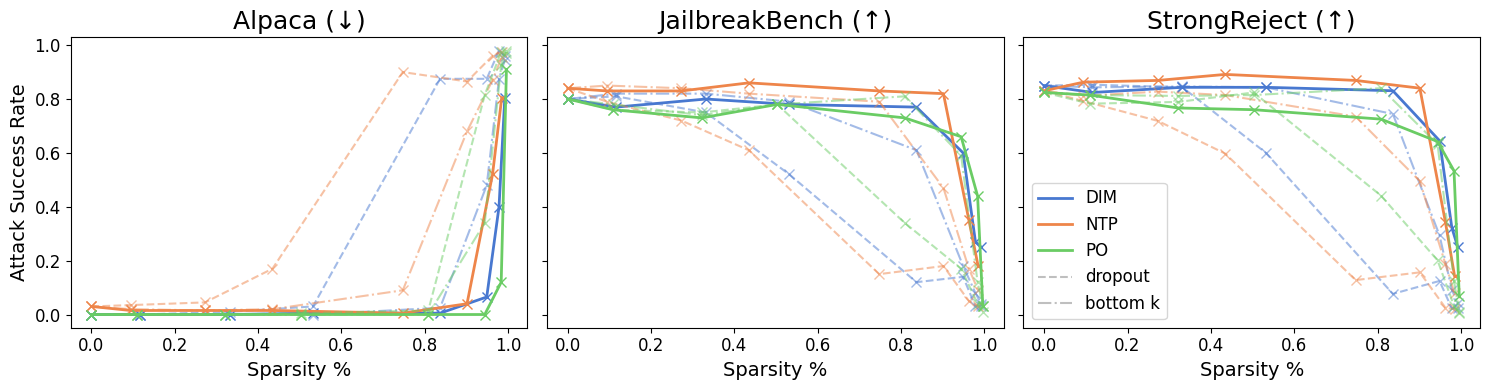

In [37]:
palette = sns.color_palette("muted", 3)
method_colors = {'DIM': palette[0], 'NTP': palette[1], 'PO': palette[2]}

datasets   = ['Alpaca (↓)', 'JailbreakBench (↑)', 'StrongReject (↑)']
ds_indices = [0, 1, 2]

# each results list is [(a_asr, jbb_asr, sr_asr), ...] with 6 entries
rtol_results    = {'DIM': dim_rtol_results,    'NTP': ntp_rtol_results,    'PO': po_rtol_results}
dropout_results = {'DIM': dim_dropout_results, 'NTP': ntp_dropout_results, 'PO': po_dropout_results}
mag_results = {'DIM': dim_mag_results, 'NTP': ntp_mag_results, 'PO': po_mag_results}

xs_dict = {
    'DIM': [n/model_dims for n in dim_dropouts],
    'NTP': [n/model_dims for n in ntp_dropouts],
    'PO': [n/model_dims for n in po_dropouts]
}
print(xs_dict)
x_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, ds_name, ds_idx in zip(axes, datasets, ds_indices):
    for method, color in method_colors.items():
        rtol_vals    = [r[ds_idx] for r in rtol_results[method]]
        dropout_vals = [r[ds_idx] for r in dropout_results[method]]
        mag_vals = [r[ds_idx] for r in mag_results[method]]

        ax.plot(xs_dict[method], rtol_vals,    color=color, linestyle='-', marker='x', markersize=7, linewidth=2,   label=f'{method} (rtol)')
        ax.plot(xs_dict[method], dropout_vals, color=color, linestyle='--', marker='x', markersize=7, linewidth=1.5, alpha=0.5, label=f'{method} (dropout)')
        ax.plot(xs_dict[method], mag_vals, color=color, linestyle='-.', marker='x', markersize=7, linewidth=1.5, alpha=0.5, label=f'{method} (bottom k)')

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticks, fontsize=12)
    ax.set_xlabel('Sparsity %', fontsize=14)
    ax.set_title(ds_name, fontsize=18)

axes[0].tick_params('y', labelsize=12)
axes[0].set_ylabel('Attack Success Rate', fontsize=14)

# build legend with one entry per method (solid) + one for dropout style
from matplotlib.lines import Line2D
legend_handles = [
    *[Line2D([0], [0], color=method_colors[m], linewidth=2, label=m) for m in method_colors],
    Line2D([0], [0], color='gray', linewidth=1.5, linestyle='--', alpha=0.5, label='dropout'),
    Line2D([0], [0], color='gray', linewidth=1.5, linestyle='-.', alpha=0.5, label='bottom k'),
]
axes[-1].legend(handles=legend_handles, fontsize=12, loc='best')

# plt.suptitle('Sparse Steering Vector Evaluation (Gemma 2 2B)', fontsize=13)
plt.tight_layout()
# plt.savefig('sparsity_g2.pdf', bbox_inches='tight')
plt.show()


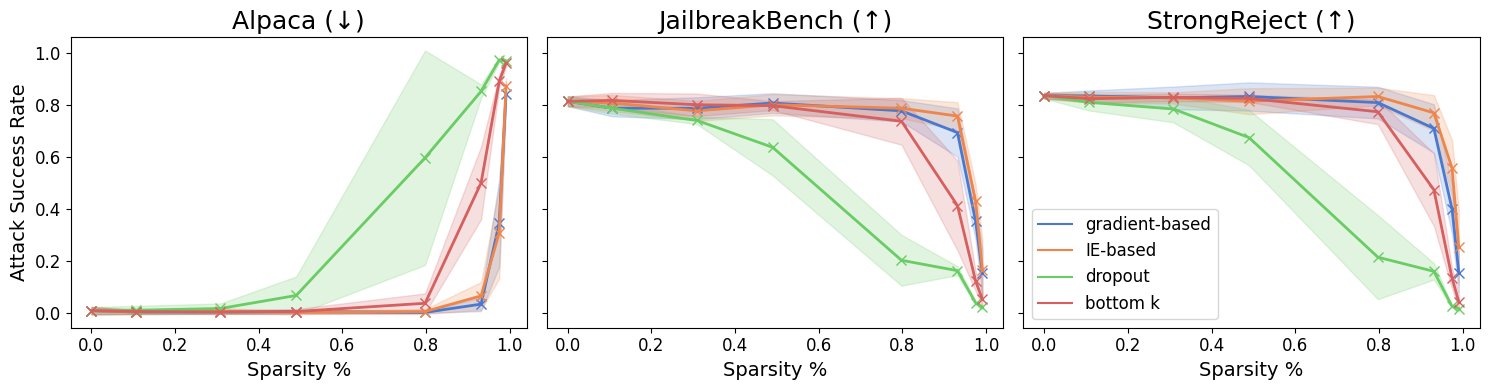

In [32]:
palette = sns.color_palette("muted", 4)
method_colors = {'DIM': palette[0], 'NTP': palette[1], 'PO': palette[2]}

datasets   = ['Alpaca (↓)', 'JailbreakBench (↑)', 'StrongReject (↑)']
ds_indices = [0, 1, 2]

# each results list is [(a_asr, jbb_asr, sr_asr), ...] with 6 entries
avg_rtol_results, std_rtol_results = get_avg_results(dim_rtol_results, ntp_rtol_results, po_rtol_results)
avg_dropout_results, std_dropout_results = get_avg_results(dim_dropout_results, ntp_dropout_results, po_dropout_results)
avg_mag_results, std_mag_results = get_avg_results(dim_mag_results, ntp_mag_results, po_mag_results)
avg_ie_results, std_ie_results = get_avg_results(dim_ie_results, ntp_ie_results, po_ie_results)

xs_dict = [(n1+n2+n3)/(3*model_dims) for n1,n2,n3 in zip(dim_dropouts, ntp_dropouts, po_dropouts)]

x_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, ds_name, ds_idx in zip(axes, datasets, ds_indices):
    rtol_vals    = [r[ds_idx] for r in avg_rtol_results]
    dropout_vals = [r[ds_idx] for r in avg_dropout_results]
    mag_vals     = [r[ds_idx] for r in avg_mag_results]
    ie_vals     = [r[ds_idx] for r in avg_ie_results]

    rtol_std    = [r[ds_idx] for r in std_rtol_results]
    dropout_std = [r[ds_idx] for r in std_dropout_results]
    mag_std     = [r[ds_idx] for r in std_mag_results]
    ie_std     = [r[ds_idx] for r in std_ie_results]

    ax.plot(xs_dict, rtol_vals,    color=palette[0], linestyle="-", marker="x", markersize=7, linewidth=2,   label="gradient-based")
    ax.fill_between(xs_dict, [v-s for v,s in zip(rtol_vals, rtol_std)], [v+s for v,s in zip(rtol_vals, rtol_std)], color=palette[0], alpha=0.2)
    
    ax.plot(xs_dict, ie_vals,     color=palette[1], linestyle="-", marker="x", markersize=7, linewidth=2, label="IE-based")
    ax.fill_between(xs_dict, [v-s for v,s in zip(ie_vals, ie_std)], [v+s for v,s in zip(ie_vals, ie_std)], color=palette[1], alpha=0.2)

    ax.plot(xs_dict, dropout_vals, color=palette[2], linestyle="-", marker="x", markersize=7, linewidth=2, label="dropout")
    ax.fill_between(xs_dict, [v-s for v,s in zip(dropout_vals, dropout_std)], [v+s for v,s in zip(dropout_vals, dropout_std)], color=palette[2], alpha=0.2)

    ax.plot(xs_dict, mag_vals,     color=palette[3], linestyle="-", marker="x", markersize=7, linewidth=2, label="bottom k")
    ax.fill_between(xs_dict, [v-s for v,s in zip(mag_vals, mag_std)], [v+s for v,s in zip(mag_vals, mag_std)], color=palette[3], alpha=0.2)

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticks, fontsize=12)
    ax.set_xlabel("Sparsity %", fontsize=14)
    ax.set_title(ds_name, fontsize=18)

axes[0].tick_params("y", labelsize=12)
axes[0].set_ylabel("Attack Success Rate", fontsize=14)

# build legend with one entry per method (solid) + one for dropout style
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=palette[0], linewidth=1.5, linestyle="-", label="gradient-based"),
    Line2D([0], [0], color=palette[1], linewidth=1.5, linestyle="-", label="IE-based"),
    Line2D([0], [0], color=palette[2], linewidth=1.5, linestyle="-", label="dropout"),
    Line2D([0], [0], color=palette[3], linewidth=1.5, linestyle="-", label="bottom k"),
]
axes[-1].legend(handles=legend_handles, fontsize=12, loc="best")

# plt.suptitle("Sparse Steering Vector Evaluation (Gemma 2 2B)", fontsize=13)
plt.tight_layout()
plt.savefig("sparsity_g2_avg.pdf", bbox_inches="tight")
plt.show()


get similarities of sparse vectors. Is in the paper

In [23]:
# load sparse vectors
path = f"../vectors/{g2_model_path.split('/')[-1]}"

# load dim rtol vecs
dim_rtol_vectors = []
for i, val in enumerate(rtols):
    if i == 0:
        sparse_vec = t.load('../pipeline/runs/gemma-2-2b-it/direction_layer15_pos-1.pt', map_location='cpu').to(t.float32)
    else:
        sparse_vec = t.load(os.path.join(path, f"dim_logit_rtol={val}.pt"), map_location='cpu')['direction']
    dim_rtol_vectors.append(sparse_vec)

# load ntp rtol vecs
ntp_rtol_vectors = []
for i, val in enumerate(rtols):
    if i == 0:
        sparse_vec = t.load('../trained_vectors/gemma-2-2b-it/ntp_bsz6_lr1e-2_seed42/direction_8.pt').to(t.float32)
    else:
        sparse_vec = t.load(os.path.join(path, f"ntp_logit_rtol={val}.pt"), map_location='cpu')['direction']
    ntp_rtol_vectors.append(sparse_vec)

# load po rtol vecs
po_rtol_vectors = []
for i, val in enumerate(rtols):
    if i == 0:
        sparse_vec = t.load('../trained_vectors/gemma-2-2b-it/reps_bsz6_lr1e-2_ss2e-2_seed5/direction_1.pt').to(t.float32)
    else:
        sparse_vec = t.load(os.path.join(path, f"reps_logit_rtol={val}.pt"), map_location='cpu')['direction']
    po_rtol_vectors.append(sparse_vec)

In [13]:
# load sparse vectors
path = f"../vectors/{g2_model_path.split('/')[-1]}"

# load dim rtol vecs
dim_mag_vectors = []
for i, val in enumerate(dim_dropouts):
    if i == 0:
        sparse_vec = t.load('../pipeline/runs/gemma-2-2b-it/direction_layer15_pos-1.pt', map_location='cpu').to(t.float32)
    else:
        sparse_vec = t.load(os.path.join(path, f"dim_logit_mag={val}.pt"), map_location='cpu')['direction']
    dim_mag_vectors.append(sparse_vec)

# load ntp rtol vecs
ntp_mag_vectors = []
for i, val in enumerate(ntp_dropouts):
    if i == 0:
        sparse_vec = t.load('../trained_vectors/gemma-2-2b-it/ntp_bsz6_lr1e-2_seed42/direction_8.pt').to(t.float32)
    else:
        sparse_vec = t.load(os.path.join(path, f"ntp_logit_mag={val}.pt"), map_location='cpu')['direction']
    ntp_mag_vectors.append(sparse_vec)

# load po rtol vecs
po_mag_vectors = []
for i, val in enumerate(po_dropouts):
    if i == 0:
        sparse_vec = t.load('../trained_vectors/gemma-2-2b-it/reps_bsz6_lr1e-2_ss2e-2_seed5/direction_1.pt').to(t.float32)
    else:
        sparse_vec = t.load(os.path.join(path, f"reps_logit_mag={val}.pt"), map_location='cpu')['direction']
    po_mag_vectors.append(sparse_vec)

In [14]:
# load sparse vectors
path = f"../vectors/{g2_model_path.split('/')[-1]}"

# load dim rtol vecs
dim_ie_vectors = []
for i, val in enumerate(dim_dropouts):
    if i == 0:
        sparse_vec = t.load('../pipeline/runs/gemma-2-2b-it/direction_layer15_pos-1.pt', map_location='cpu').to(t.float32)
    else:
        sparse_vec = t.load(os.path.join(path, f"dim_logit_ie={val}.pt"), map_location='cpu')['direction']
    dim_ie_vectors.append(sparse_vec)

# load ntp rtol vecs
ntp_ie_vectors = []
for i, val in enumerate(ntp_dropouts):
    if i == 0:
        sparse_vec = t.load('../trained_vectors/gemma-2-2b-it/ntp_bsz6_lr1e-2_seed42/direction_8.pt').to(t.float32)
    else:
        sparse_vec = t.load(os.path.join(path, f"ntp_logit_ie={val}.pt"), map_location='cpu')['direction']
    ntp_ie_vectors.append(sparse_vec)

# load po rtol vecs
po_ie_vectors = []
for i, val in enumerate(po_dropouts):
    if i == 0:
        sparse_vec = t.load('../trained_vectors/gemma-2-2b-it/reps_bsz6_lr1e-2_ss2e-2_seed5/direction_1.pt').to(t.float32)
    else:
        sparse_vec = t.load(os.path.join(path, f"reps_logit_ie={val}.pt"), map_location='cpu')['direction']
    po_ie_vectors.append(sparse_vec)

0 1.0 2304 2304 2304
0.1 0.0020285847197843206 1830 2037 2053
0.3 9.271628152104398e-16 1130 1540 1563
0.5 3.872320367060624e-36 686 1079 1146
1 3.4055006788376365e-43 177 376 441
1.5 9.564958805459857e-28 44 118 129
2 1.2359153217494034e-10 11 50 38
2.5 0.0020097367639362955 2 18 9
0 1.0 2304 2304 2304
0.1 9.089069064407507e-07 1869 2037 2087
0.3 4.1839575975406685e-47 1268 1540 1676
0.5 8.806505622736177e-101 858 1079 1303
1 1.0885207600211937e-132 297 376 582
1.5 3.1894693794980136e-93 101 118 227
2 4.2128106411399836e-48 38 50 86
2.5 1.5112592076099393e-21 13 18 35
0 1.0 2304 2304 2304
0.1 0.03976980141941574 1868 2087 2053
0.3 5.800849302139005e-10 1199 1676 1563
0.5 2.8213907584618906e-21 760 1303 1146
1 4.2430080464478755e-44 232 582 441
1.5 1.0944071456001061e-35 66 227 129
2 1.4145789182082821e-21 21 86 38
2.5 0.00025360722142003616 3 35 9


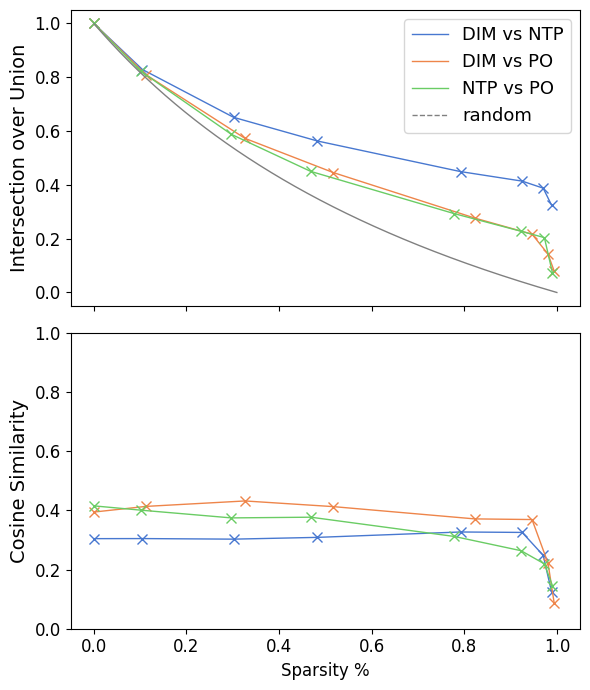

== DIM NTP ==
similarity: [tensor(0.3044), tensor(0.3046), tensor(0.3027), tensor(0.3087), tensor(0.3269), tensor(0.3254), tensor(0.2480), tensor(0.1255)]
iou: [tensor(1.), tensor(0.8288), tensor(0.6509), tensor(0.5630), tensor(0.4493), tensor(0.4139), tensor(0.3878), tensor(0.3250)]
== DIM PO ==
similarity: [tensor(0.3942), tensor(0.4133), tensor(0.4317), tensor(0.4126), tensor(0.3711), tensor(0.3689), tensor(0.2219), tensor(0.0877)]
iou: [tensor(1.), tensor(0.8097), tensor(0.5727), tensor(0.4457), tensor(0.2766), tensor(0.2167), tensor(0.1429), tensor(0.0800)]
== NTP PO ==
similarity: [tensor(0.4152), tensor(0.4006), tensor(0.3745), tensor(0.3769), tensor(0.3119), tensor(0.2637), tensor(0.2191), tensor(0.1456)]
iou: [tensor(1.), tensor(0.8222), tensor(0.5877), tensor(0.4500), tensor(0.2933), tensor(0.2276), tensor(0.2039), tensor(0.0732)]


In [24]:

def sparsity(v):
    return (v == 0).sum().item() / len(v)

dim_vectors = dim_rtol_vectors
ntp_vectors = ntp_rtol_vectors
po_vectors = po_rtol_vectors

# measure sim between dim and po
dim_po_sims = []
dim_po_ious = []
x_dim_po = []
for i in range(len(dim_ie_vectors)):
    dim_po_sims.append(get_sim(dim_vectors[i], po_vectors[i]))
    observed_iou = get_iou(dim_vectors[i]!=0, po_vectors[i]!=0)
    dim_po_ious.append(observed_iou)
    x_dim_po.append((sparsity(dim_vectors[i]) + sparsity(po_vectors[i])) / 2)
    m1 = int((dim_vectors[i]!=0).sum())
    m2 = int((po_vectors[i]!=0).sum())
    n = len(dim_vectors[i])
    observed_k = int(t.logical_and(dim_vectors[i]!=0, po_vectors[i]!=0).sum())
    p_value = hypergeom.sf(observed_k - 1, n, m1, m2)
    print(rtols[i], p_value, observed_k, m1, m2)

# measure sim between dim and ntp
dim_ntp_sims = []
dim_ntp_ious = []
x_dim_ntp = []
for i in range(len(dim_vectors)):
    dim_ntp_sims.append(get_sim(dim_vectors[i], ntp_vectors[i]))
    observed_iou = get_iou(dim_vectors[i]!=0, ntp_vectors[i]!=0)
    dim_ntp_ious.append(observed_iou)
    x_dim_ntp.append((sparsity(dim_vectors[i]) + sparsity(ntp_vectors[i])) / 2)
    m1 = int((dim_vectors[i]!=0).sum())
    m2 = int((ntp_vectors[i]!=0).sum())
    n = len(dim_vectors[i])
    observed_k = int(t.logical_and(dim_vectors[i]!=0, ntp_vectors[i]!=0).sum())
    p_value = hypergeom.sf(observed_k - 1, n, m1, m2)
    print(rtols[i], p_value, observed_k, m1, m2)

# measure sim between ntp and po
ntp_po_sims = []
ntp_po_ious = []
x_ntp_po = []
for i in range(len(dim_vectors)):
    ntp_po_sims.append(get_sim(ntp_vectors[i], po_vectors[i]))
    observed_iou = get_iou(ntp_vectors[i]!=0, po_vectors[i]!=0)
    ntp_po_ious.append(observed_iou)
    x_ntp_po.append((sparsity(ntp_vectors[i]) + sparsity(po_vectors[i])) / 2)
    m1 = int((ntp_vectors[i]!=0).sum())
    m2 = int((po_vectors[i]!=0).sum())
    n = len(ntp_vectors[i])
    observed_k = int(t.logical_and(ntp_vectors[i]!=0, po_vectors[i]!=0).sum())
    p_value = hypergeom.sf(observed_k - 1, n, m1, m2)
    print(rtols[i], p_value, observed_k, m1, m2)

# random IoU
random_ious = []
x_random = []
for i in range(g2_model_dims):
    random_ious.append(i / (2*g2_model_dims - i))
    x_random.append(1 - i/g2_model_dims)

# --- combined plot ---
from matplotlib.lines import Line2D
palette = sns.color_palette("muted", 3)
x_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
y = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

fig, (ax_iou, ax_sim) = plt.subplots(2, 1, figsize=(6, 7), sharex=True)

# bottom: cosine similarity
ax_sim.plot(x_dim_ntp, dim_ntp_sims, color=palette[0], marker='x', markersize=7, linestyle='-', linewidth=1)
ax_sim.plot(x_dim_po,  dim_po_sims,  color=palette[1], marker='x', markersize=7, linestyle='-', linewidth=1)
ax_sim.plot(x_ntp_po,  ntp_po_sims,  color=palette[2], marker='x', markersize=7, linestyle='-', linewidth=1)
ax_sim.set_yticks(y)
ax_sim.set_ylabel('Cosine Similarity', fontsize=14)
ax_sim.tick_params(axis='y', labelsize=12)
ax_sim.set_xticks(x_ticks)
ax_sim.set_xticklabels(x_ticks, fontsize=12)
ax_sim.set_xlabel('Sparsity %', fontsize=12)

# top: IoU
ax_iou.plot(x_dim_ntp, dim_ntp_ious, color=palette[0], marker='x', markersize=7, linestyle='-', linewidth=1, label='DIM vs NTP')
ax_iou.plot(x_dim_po,  dim_po_ious,  color=palette[1], marker='x', markersize=7, linestyle='-', linewidth=1, label='DIM vs PO')
ax_iou.plot(x_ntp_po,  ntp_po_ious,  color=palette[2], marker='x', markersize=7, linestyle='-', linewidth=1, label='NTP vs PO')
ax_iou.plot(x_random, random_ious, color='gray', linestyle='-', linewidth=1, label='random')
ax_iou.set_yticks(y)
ax_iou.set_ylabel('Intersection over Union', fontsize=14)
ax_iou.tick_params(axis='y', labelsize=12)

g2_x_dim_ntp = x_dim_ntp
g2_x_dim_po = x_dim_po
g2_x_ntp_po = x_ntp_po
g2_x_random = x_random
g2_dim_ntp_ious = dim_ntp_ious
g2_dim_po_ious = dim_po_ious
g2_ntp_po_ious = ntp_po_ious
g2_random_ious = random_ious

legend_handles = [
    Line2D([0], [0], color=palette[0], linewidth=1, label='DIM vs NTP'),
    Line2D([0], [0], color=palette[1], linewidth=1, label='DIM vs PO'),
    Line2D([0], [0], color=palette[2], linewidth=1, label='NTP vs PO'),
    Line2D([0], [0], color='gray', linestyle='--', linewidth=1, label='random'),
]
ax_iou.legend(handles=legend_handles, fontsize=13, loc='upper right')

plt.tight_layout()
plt.savefig('sparse_sim_iou_g2.pdf', bbox_inches='tight')
plt.show()

print('== DIM NTP ==')
print(f'similarity: {dim_ntp_sims}')
print(f'iou: {dim_ntp_ious}')

print('== DIM PO ==')
print(f'similarity: {dim_po_sims}')
print(f'iou: {dim_po_ious}')

print('== NTP PO ==')
print(f'similarity: {ntp_po_sims}')
print(f'iou: {ntp_po_ious}')


now plot sparsities of Llama 3.2 3B, which goes in appendix

In [19]:
l3_model_path = 'meta-llama/Llama-3.2-3B-Instruct'
l3_model_dims = model_dims_dict[l3_model_path]

dim_dropouts = [0, 312, 969, 1591, 2564, 2954, 3050, 3063]
ntp_dropouts = [0, 311, 859, 1377, 2394, 2845, 3009, 3059]
po_dropouts = [0, 284, 865, 1380, 2339, 2829, 2999, 3055]
rtols = [0, 0.1, 0.3, 0.5, 1, 1.5, 2, 2.5]
[n/l3_model_dims for n in dim_dropouts]

[0.0,
 0.1015625,
 0.3154296875,
 0.5179036458333334,
 0.8346354166666666,
 0.9615885416666666,
 0.9928385416666666,
 0.9970703125]

In [34]:
dim_rtol_results = get_sparse_results('rtol', rtols, 'dim_logit', l3_model_path)
dim_dropout_results = get_sparse_results('dropout', dim_dropouts, 'dim_logit', l3_model_path)
dim_mag_results = get_sparse_results('mag', dim_dropouts, 'dim_logit', l3_model_path)
dim_ie_results = get_sparse_results('ie', dim_dropouts, 'dim_logit', l3_model_path)
ntp_rtol_results = get_sparse_results('rtol', rtols, 'ntp_logit', l3_model_path)
ntp_dropout_results = get_sparse_results('dropout', ntp_dropouts, 'ntp_logit', l3_model_path)
ntp_mag_results = get_sparse_results('mag', ntp_dropouts, 'ntp_logit', l3_model_path)
ntp_ie_results = get_sparse_results('ie', ntp_dropouts, 'ntp_logit', l3_model_path)
po_rtol_results = get_sparse_results('rtol', rtols, 'reps_logit', l3_model_path)
po_dropout_results = get_sparse_results('dropout', po_dropouts, 'reps_logit', l3_model_path)
po_mag_results = get_sparse_results('mag', po_dropouts, 'reps_logit', l3_model_path)
po_ie_results = get_sparse_results('ie', po_dropouts, 'reps_logit', l3_model_path)
model_dims = model_dims_dict[l3_model_path]

In [28]:
print(dim_rtol_results)
print(dim_dropout_results)
print(dim_mag_results)
print(ntp_rtol_results)
print(ntp_dropout_results)
print(ntp_mag_results)
print(po_rtol_results)
print(po_dropout_results)
print(po_mag_results)

[(0.03, 0.85, 0.8722044728434505), (0.01, 0.82, 0.8562300319488818), (0.015, 0.83, 0.8626198083067093), (0.01, 0.83, 0.8594249201277955), (0.01, 0.84, 0.8242811501597445), (0.035, 0.83, 0.8274760383386581), (0.885, 0.74, 0.8115015974440895), (0.955, 0.76, 0.8274760383386581)]
[(0.03, 0.85, 0.8722044728434505), (0.03, 0.82, 0.8690095846645367), (0.02, 0.87, 0.8849840255591054), (0.04, 0.8, 0.8562300319488818), (0.78, 0.59, 0.6741214057507987), (0.965, 0.22, 0.28115015974440893), (0.995, 0.28, 0.3769968051118211), (0.995, 0.1, 0.13099041533546327)]
[(0.03, 0.85, 0.8722044728434505), (0.015, 0.82, 0.8626198083067093), (0.015, 0.82, 0.8562300319488818), (0.02, 0.8, 0.8626198083067093), (0.005, 0.8, 0.8594249201277955), (0.66, 0.67, 0.7571884984025559), (0.955, 0.18, 0.26198083067092653), (0.99, 0.09, 0.10862619808306709)]
[(0.0, 0.83, 0.8817891373801917), (0.0, 0.84, 0.8913738019169329), (0.0, 0.76, 0.865814696485623), (0.0, 0.83, 0.8498402555910544), (0.0, 0.75, 0.8115015974440895), (0.0,

{'DIM': [0.0, 0.1015625, 0.3154296875, 0.5179036458333334, 0.8346354166666666, 0.9615885416666666, 0.9928385416666666, 0.9970703125], 'NTP': [0.0, 0.10123697916666667, 0.2796223958333333, 0.4482421875, 0.779296875, 0.9261067708333334, 0.9794921875, 0.9957682291666666], 'PO': [0.0, 0.09244791666666667, 0.2815755208333333, 0.44921875, 0.7613932291666666, 0.9208984375, 0.9762369791666666, 0.9944661458333334]}


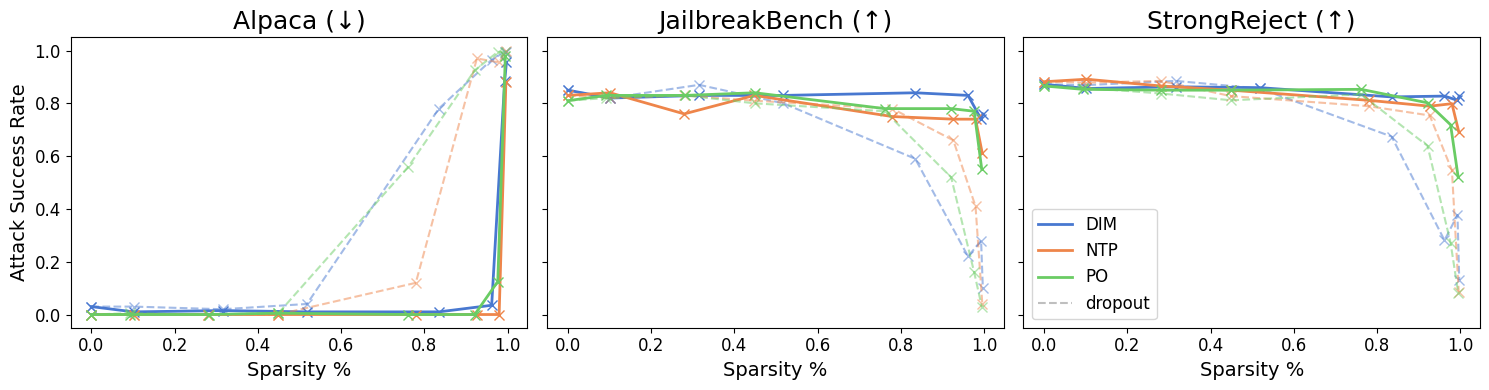

In [29]:
palette = sns.color_palette("muted", 3)
method_colors = {'DIM': palette[0], 'NTP': palette[1], 'PO': palette[2]}

datasets   = ['Alpaca (↓)', 'JailbreakBench (↑)', 'StrongReject (↑)']
ds_indices = [0, 1, 2]

# each results list is [(a_asr, jbb_asr, sr_asr), ...] with 6 entries
rtol_results    = {'DIM': dim_rtol_results,    'NTP': ntp_rtol_results,    'PO': po_rtol_results}
dropout_results = {'DIM': dim_dropout_results, 'NTP': ntp_dropout_results, 'PO': po_dropout_results}

xs_dict = {
    'DIM': [n/model_dims for n in dim_dropouts],
    'NTP': [n/model_dims for n in ntp_dropouts],
    'PO': [n/model_dims for n in po_dropouts]
}
print(xs_dict)
x_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, ds_name, ds_idx in zip(axes, datasets, ds_indices):
    for method, color in method_colors.items():
        rtol_vals    = [r[ds_idx] for r in rtol_results[method]]
        dropout_vals = [r[ds_idx] for r in dropout_results[method]]

        ax.plot(xs_dict[method], rtol_vals,    color=color, linestyle='-', marker='x', markersize=7, linewidth=2,   label=f'{method} (rtol)')
        ax.plot(xs_dict[method], dropout_vals, color=color, linestyle='--', marker='x', markersize=7, linewidth=1.5, alpha=0.5, label=f'{method} (dropout)')

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticks, fontsize=12)
    ax.set_xlabel('Sparsity %', fontsize=14)
    ax.set_title(ds_name, fontsize=18)

axes[0].tick_params('y', labelsize=12)
axes[0].set_ylabel('Attack Success Rate', fontsize=14)

# build legend with one entry per method (solid) + one for dropout style
from matplotlib.lines import Line2D
legend_handles = [
    *[Line2D([0], [0], color=method_colors[m], linewidth=2, label=m) for m in method_colors],
    Line2D([0], [0], color='gray', linewidth=1.5, linestyle='--', alpha=0.5, label='dropout'),
]
axes[-1].legend(handles=legend_handles, fontsize=12, loc='best')

# plt.suptitle('Sparse Steering Vector Evaluation (Gemma 2 2B)', fontsize=13)
plt.tight_layout()
plt.savefig('sparsity_l3.pdf', bbox_inches='tight')
plt.show()


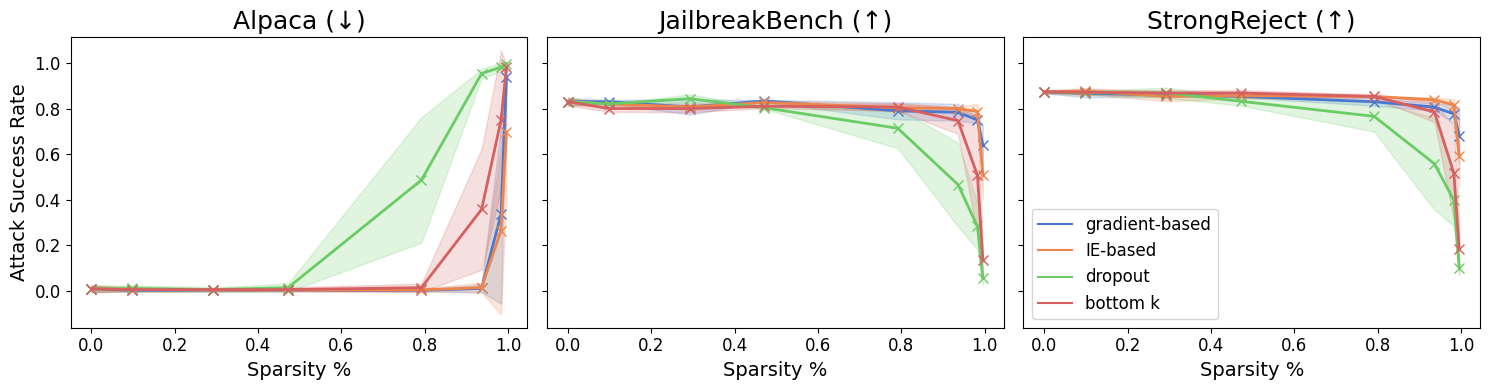

In [35]:
palette = sns.color_palette("muted", 4)
method_colors = {'DIM': palette[0], 'NTP': palette[1], 'PO': palette[2]}

datasets   = ['Alpaca (↓)', 'JailbreakBench (↑)', 'StrongReject (↑)']
ds_indices = [0, 1, 2]

# each results list is [(a_asr, jbb_asr, sr_asr), ...] with 6 entries
avg_rtol_results, std_rtol_results = get_avg_results(dim_rtol_results, ntp_rtol_results, po_rtol_results)
avg_dropout_results, std_dropout_results = get_avg_results(dim_dropout_results, ntp_dropout_results, po_dropout_results)
avg_mag_results, std_mag_results = get_avg_results(dim_mag_results, ntp_mag_results, po_mag_results)
avg_ie_results, std_ie_results = get_avg_results(dim_ie_results, ntp_ie_results, po_ie_results)

xs_dict = [(n1+n2+n3)/(3*model_dims) for n1,n2,n3 in zip(dim_dropouts, ntp_dropouts, po_dropouts)]

x_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, ds_name, ds_idx in zip(axes, datasets, ds_indices):
    rtol_vals    = [r[ds_idx] for r in avg_rtol_results]
    dropout_vals = [r[ds_idx] for r in avg_dropout_results]
    mag_vals     = [r[ds_idx] for r in avg_mag_results]
    ie_vals     = [r[ds_idx] for r in avg_ie_results]

    rtol_std    = [r[ds_idx] for r in std_rtol_results]
    dropout_std = [r[ds_idx] for r in std_dropout_results]
    mag_std     = [r[ds_idx] for r in std_mag_results]
    ie_std     = [r[ds_idx] for r in std_ie_results]

    ax.plot(xs_dict, rtol_vals,    color=palette[0], linestyle="-", marker="x", markersize=7, linewidth=2,   label="gradient-based")
    ax.fill_between(xs_dict, [v-s for v,s in zip(rtol_vals, rtol_std)], [v+s for v,s in zip(rtol_vals, rtol_std)], color=palette[0], alpha=0.2)
    
    ax.plot(xs_dict, ie_vals,     color=palette[1], linestyle="-", marker="x", markersize=7, linewidth=2, label="IE-based")
    ax.fill_between(xs_dict, [v-s for v,s in zip(ie_vals, ie_std)], [v+s for v,s in zip(ie_vals, ie_std)], color=palette[1], alpha=0.2)

    ax.plot(xs_dict, dropout_vals, color=palette[2], linestyle="-", marker="x", markersize=7, linewidth=2, label="dropout")
    ax.fill_between(xs_dict, [v-s for v,s in zip(dropout_vals, dropout_std)], [v+s for v,s in zip(dropout_vals, dropout_std)], color=palette[2], alpha=0.2)

    ax.plot(xs_dict, mag_vals,     color=palette[3], linestyle="-", marker="x", markersize=7, linewidth=2, label="bottom k")
    ax.fill_between(xs_dict, [v-s for v,s in zip(mag_vals, mag_std)], [v+s for v,s in zip(mag_vals, mag_std)], color=palette[3], alpha=0.2)

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticks, fontsize=12)
    ax.set_xlabel("Sparsity %", fontsize=14)
    ax.set_title(ds_name, fontsize=18)

axes[0].tick_params("y", labelsize=12)
axes[0].set_ylabel("Attack Success Rate", fontsize=14)

# build legend with one entry per method (solid) + one for dropout style
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=palette[0], linewidth=1.5, linestyle="-", label="gradient-based"),
    Line2D([0], [0], color=palette[1], linewidth=1.5, linestyle="-", label="IE-based"),
    Line2D([0], [0], color=palette[2], linewidth=1.5, linestyle="-", label="dropout"),
    Line2D([0], [0], color=palette[3], linewidth=1.5, linestyle="-", label="bottom k"),
]
axes[-1].legend(handles=legend_handles, fontsize=12, loc="best")

# plt.suptitle("Sparse Steering Vector Evaluation (Gemma 2 2B)", fontsize=13)
plt.tight_layout()
plt.savefig("sparsity_l3_avg.pdf", bbox_inches="tight")
plt.show()


In [ ]:
# load sparse vectors
path = f"../vectors/{l3_model_path.split('/')[-1]}"
bszs = [6, 12]
lrs = ['1e-2', '4e-2']

# load dim rtol vecs
dim_rtol_vectors = []
for i, val in enumerate(rtols):
    if i == 0:
        sparse_vec = t.load('../pipeline/runs/Llama-3.2-3B-Instruct/direction_layer12_pos-4.pt', map_location='cpu').to(t.float32)
    else:
        sparse_vec = t.load(os.path.join(path, f"dim_logit_rtol={val}.pt"), map_location='cpu')['direction']
    dim_rtol_vectors.append(sparse_vec)

# load ntp rtol vecs
ntp_rtol_vectors = []
for i, val in enumerate(rtols):
    if i == 0:
        sparse_vec = t.load('../trained_vectors/Llama-3.2-3B-Instruct/ntp_bsz12_lr1e-2_seed5/direction_9.pt').to(t.float32)
    else:
        sparse_vec = t.load(os.path.join(path, f"ntp_logit_rtol={val}.pt"), map_location='cpu')['direction']
    ntp_rtol_vectors.append(sparse_vec)

# load po rtol vecs
po_rtol_vectors = []
for i, val in enumerate(rtols):
    if i == 0:
        sparse_vec = t.load('../trained_vectors/Llama-3.2-3B-Instruct/reps_bsz12_lr1e-2_ss1e-5_seed5/direction_2.pt').to(t.float32)
    else:
        sparse_vec = t.load(os.path.join(path, f"reps_logit_rtol={val}.pt"), map_location='cpu')['direction']
    po_rtol_vectors.append(sparse_vec)

In [27]:
# load sparse vectors
path = f"../vectors/{l3_model_path.split('/')[-1]}"
bszs = [6, 12]
lrs = ['1e-2', '4e-2']

# load dim rtol vecs
dim_ie_vectors = []
for i, val in enumerate(dim_dropouts):
    if i == 0:
        sparse_vec = t.load('../pipeline/runs/Llama-3.2-3B-Instruct/direction_layer12_pos-4.pt', map_location='cpu').to(t.float32)
    else:
        sparse_vec = t.load(os.path.join(path, f"dim_logit_ie={val}.pt"), map_location='cpu')['direction']
    dim_ie_vectors.append(sparse_vec)

# load ntp rtol vecs
ntp_ie_vectors = []
for i, val in enumerate(ntp_dropouts):
    if i == 0:
        sparse_vec = t.load('../trained_vectors/Llama-3.2-3B-Instruct/ntp_bsz12_lr1e-2_seed5/direction_9.pt').to(t.float32)
    else:
        sparse_vec = t.load(os.path.join(path, f"ntp_logit_ie={val}.pt"), map_location='cpu')['direction']
    ntp_ie_vectors.append(sparse_vec)

# load po rtol vecs
po_ie_vectors = []
for i, val in enumerate(po_dropouts):
    if i == 0:
        sparse_vec = t.load('../trained_vectors/Llama-3.2-3B-Instruct/reps_bsz12_lr1e-2_ss1e-5_seed5/direction_2.pt').to(t.float32)
    else:
        sparse_vec = t.load(os.path.join(path, f"reps_logit_ie={val}.pt"), map_location='cpu')['direction']
    po_ie_vectors.append(sparse_vec)

0 1.0 3072 3072 3072
0.1 0.12307094448476316 2511 2760 2788
0.3 1.5440154348934097e-05 1560 2103 2207
0.5 1.8173524606600648e-08 892 1481 1692
1 2.5879525268176374e-07 167 508 733
1.5 9.672948204995287e-06 24 118 243
2 8.081851764885045e-06 6 22 73
2.5 1.0 0 9 17
0 1.0 3072 3072 3072
0.1 2.458979517511971e-06 2506 2760 2761
0.3 7.351162126155214e-24 1633 2103 2213
0.5 2.5429970088169276e-40 999 1481 1695
1 3.731031549350112e-53 253 508 678
1.5 1.547641384323796e-25 48 118 227
2 1.4407010905343468e-10 9 22 63
2.5 0.0005854054816524789 2 9 13
0 1.0 3072 3072 3072
0.1 0.08449810844923347 2513 2761 2788
0.3 1.1298677348857816e-07 1649 2213 2207
0.5 3.593096725637509e-12 1028 1695 1692
1 5.096390604539114e-21 257 678 733
1.5 3.615596125238096e-14 53 227 243
2 9.363997624573501e-05 8 63 73
2.5 1.0 0 13 17


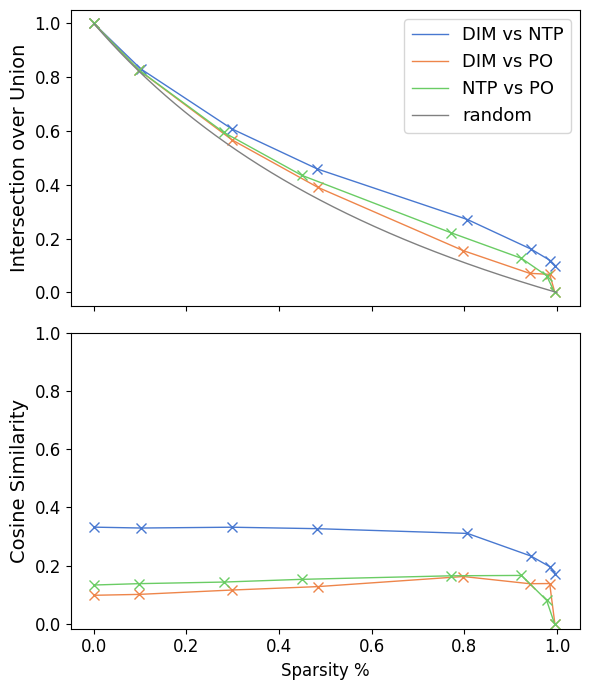

== DIM NTP ==
similarity: [tensor(0.3323), tensor(0.3293), tensor(0.3321), tensor(0.3271), tensor(0.3108), tensor(0.2332), tensor(0.1952), tensor(0.1716)]
iou: [tensor(1.), tensor(0.8312), tensor(0.6086), tensor(0.4589), tensor(0.2712), tensor(0.1616), tensor(0.1184), tensor(0.1000)]
== DIM PO ==
similarity: [tensor(0.0982), tensor(0.1013), tensor(0.1163), tensor(0.1280), tensor(0.1627), tensor(0.1380), tensor(0.1386), tensor(0.)]
iou: [tensor(1.), tensor(0.8268), tensor(0.5673), tensor(0.3911), tensor(0.1555), tensor(0.0712), tensor(0.0674), tensor(0.)]
== NTP PO ==
similarity: [tensor(0.1335), tensor(0.1382), tensor(0.1437), tensor(0.1530), tensor(0.1651), tensor(0.1665), tensor(0.0811), tensor(0.)]
iou: [tensor(1.), tensor(0.8277), tensor(0.5951), tensor(0.4358), tensor(0.2227), tensor(0.1271), tensor(0.0625), tensor(0.)]


In [28]:
def get_sim(v1, v2):
    return t.cosine_similarity(v1, v2, dim=0)

def get_iou(v1, v2):
    intersection = t.logical_and(v1, v2).sum()
    union = t.logical_or(v1, v2).sum()
    return intersection / union

def sparsity(v):
    return (v == 0).sum().item() / len(v)

dim_vectors = dim_ie_vectors
ntp_vectors = ntp_ie_vectors
po_vectors = po_ie_vectors

# measure sim between dim and po
dim_po_sims = []
dim_po_ious = []
x_dim_po = []
for i in range(len(dim_vectors)):
    dim_po_sims.append(get_sim(dim_vectors[i], po_vectors[i]))
    observed_iou = get_iou(dim_vectors[i]!=0, po_vectors[i]!=0)
    dim_po_ious.append(observed_iou)
    x_dim_po.append((sparsity(dim_vectors[i]) + sparsity(po_vectors[i])) / 2)
    m1 = int((dim_vectors[i]!=0).sum())
    m2 = int((po_vectors[i]!=0).sum())
    n = len(dim_vectors[i])
    observed_k = int(t.logical_and(dim_vectors[i]!=0, po_vectors[i]!=0).sum())
    p_value = hypergeom.sf(observed_k - 1, n, m1, m2)
    print(rtols[i], p_value, observed_k, m1, m2)

# measure sim between dim and ntp
dim_ntp_sims = []
dim_ntp_ious = []
x_dim_ntp = []
for i in range(len(dim_vectors)):
    dim_ntp_sims.append(get_sim(dim_vectors[i], ntp_vectors[i]))
    observed_iou = get_iou(dim_vectors[i]!=0, ntp_vectors[i]!=0)
    dim_ntp_ious.append(observed_iou)
    x_dim_ntp.append((sparsity(dim_vectors[i]) + sparsity(ntp_vectors[i])) / 2)
    m1 = int((dim_vectors[i]!=0).sum())
    m2 = int((ntp_vectors[i]!=0).sum())
    n = len(dim_vectors[i])
    observed_k = int(t.logical_and(dim_vectors[i]!=0, ntp_vectors[i]!=0).sum())
    p_value = hypergeom.sf(observed_k - 1, n, m1, m2)
    print(rtols[i], p_value, observed_k, m1, m2)

# measure sim between ntp and po
ntp_po_sims = []
ntp_po_ious = []
x_ntp_po = []
for i in range(len(dim_vectors)):
    ntp_po_sims.append(get_sim(ntp_vectors[i], po_vectors[i]))
    observed_iou = get_iou(ntp_vectors[i]!=0, po_vectors[i]!=0)
    ntp_po_ious.append(observed_iou)
    x_ntp_po.append((sparsity(ntp_vectors[i]) + sparsity(po_vectors[i])) / 2)
    m1 = int((ntp_vectors[i]!=0).sum())
    m2 = int((po_vectors[i]!=0).sum())
    n = len(ntp_vectors[i])
    observed_k = int(t.logical_and(ntp_vectors[i]!=0, po_vectors[i]!=0).sum())
    p_value = hypergeom.sf(observed_k - 1, n, m1, m2)
    print(rtols[i], p_value, observed_k, m1, m2)

# random IoU
random_ious = []
x_random = []
for i in range(l3_model_dims):
    random_ious.append(i / (2*l3_model_dims - i))
    x_random.append(1 - i/l3_model_dims)

# --- combined plot ---
from matplotlib.lines import Line2D
palette = sns.color_palette("muted", 3)
x_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
y = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

fig, (ax_iou, ax_sim) = plt.subplots(2, 1, figsize=(6, 7), sharex=True)

# bottom: cosine similarity
ax_sim.plot(x_dim_ntp, dim_ntp_sims, color=palette[0], marker='x', markersize=7, linestyle='-', linewidth=1)
ax_sim.plot(x_dim_po,  dim_po_sims,  color=palette[1], marker='x', markersize=7, linestyle='-', linewidth=1)
ax_sim.plot(x_ntp_po,  ntp_po_sims,  color=palette[2], marker='x', markersize=7, linestyle='-', linewidth=1)
ax_sim.set_yticks(y)
ax_sim.set_ylabel('Cosine Similarity', fontsize=14)
ax_sim.tick_params(axis='y', labelsize=12)
ax_sim.set_xticks(x_ticks)
ax_sim.set_xticklabels(x_ticks, fontsize=12)
ax_sim.set_xlabel('Sparsity %', fontsize=12)

# top: IoU
ax_iou.plot(x_dim_ntp, dim_ntp_ious, color=palette[0], marker='x', markersize=7, linestyle='-', linewidth=1, label='DIM vs NTP')
ax_iou.plot(x_dim_po,  dim_po_ious,  color=palette[1], marker='x', markersize=7, linestyle='-', linewidth=1, label='DIM vs PO')
ax_iou.plot(x_ntp_po,  ntp_po_ious,  color=palette[2], marker='x', markersize=7, linestyle='-', linewidth=1, label='NTP vs PO')
ax_iou.plot(x_random, random_ious, color='gray', linestyle='-', linewidth=1, label='random')
ax_iou.set_yticks(y)
ax_iou.set_ylabel('Intersection over Union', fontsize=14)
ax_iou.tick_params(axis='y', labelsize=12)

l3_x_random = x_random
l3_x_dim_ntp = x_dim_ntp
l3_x_dim_po = x_dim_po
l3_x_ntp_po = x_ntp_po
l3_dim_ntp_ious = dim_ntp_ious
l3_dim_po_ious = dim_po_ious
l3_ntp_po_ious = ntp_po_ious
l3_random_ious = random_ious

legend_handles = [
    Line2D([0], [0], color=palette[0], linewidth=1, label='DIM vs NTP'),
    Line2D([0], [0], color=palette[1], linewidth=1, label='DIM vs PO'),
    Line2D([0], [0], color=palette[2], linewidth=1, label='NTP vs PO'),
    Line2D([0], [0], color='gray',     linewidth=1, label='random'),
]
ax_iou.legend(handles=legend_handles, fontsize=13, loc='upper right')

plt.tight_layout()
plt.savefig('sparse_sim_iou_l3.pdf', bbox_inches='tight')
plt.show()

print('== DIM NTP ==')
print(f'similarity: {dim_ntp_sims}')
print(f'iou: {dim_ntp_ious}')

print('== DIM PO ==')
print(f'similarity: {dim_po_sims}')
print(f'iou: {dim_po_ious}')

print('== NTP PO ==')
print(f'similarity: {ntp_po_sims}')
print(f'iou: {ntp_po_ious}')


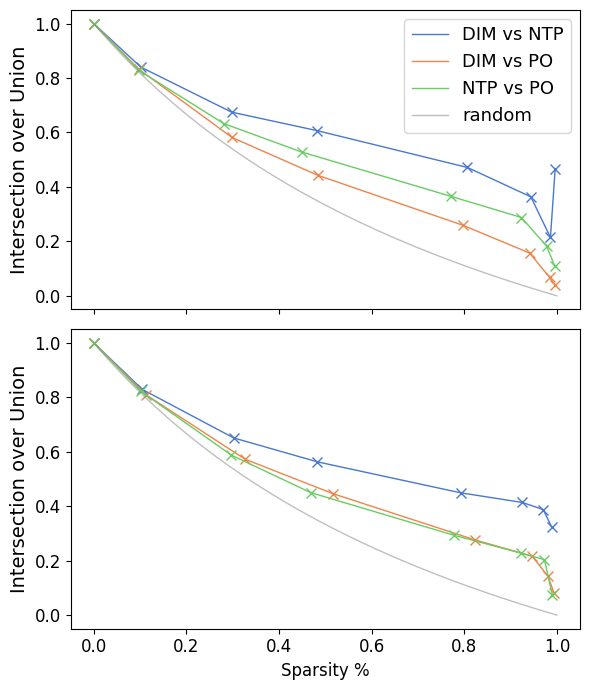

== DIM NTP ==
similarity: [tensor(0.3323), tensor(0.3334), tensor(0.3346), tensor(0.3518), tensor(0.3786), tensor(0.4637), tensor(0.2731), tensor(0.5054)]
iou: [tensor(1.), tensor(0.8403), tensor(0.6748), tensor(0.6065), tensor(0.4715), tensor(0.3636), tensor(0.2143), tensor(0.4667)]
== DIM PO ==
similarity: [tensor(0.0982), tensor(0.1135), tensor(0.1400), tensor(0.1695), tensor(0.2168), tensor(0.1694), tensor(0.1303), tensor(0.0514)]
iou: [tensor(1.), tensor(0.8328), tensor(0.5817), tensor(0.4429), tensor(0.2586), tensor(0.1571), tensor(0.0674), tensor(0.0400)]
== NTP PO ==
similarity: [tensor(0.1335), tensor(0.1439), tensor(0.1635), tensor(0.1860), tensor(0.2338), tensor(0.2310), tensor(0.2078), tensor(0.1152)]
iou: [tensor(1.), tensor(0.8289), tensor(0.6328), tensor(0.5284), tensor(0.3659), tensor(0.2877), tensor(0.1826), tensor(0.1111)]


In [35]:

# --- combined plot ---
from matplotlib.lines import Line2D
palette = sns.color_palette("muted", 3)
x_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
y = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

fig, (ax_l3, ax_g2) = plt.subplots(2, 1, figsize=(6, 7), sharex=True)

# bottom: IoU 
ax_g2.plot(g2_x_dim_ntp, g2_dim_ntp_ious, color=palette[0], marker='x', markersize=7, linestyle='-', linewidth=1, label='DIM vs NTP')
ax_g2.plot(g2_x_dim_po,  g2_dim_po_ious,  color=palette[1], marker='x', markersize=7, linestyle='-', linewidth=1, label='DIM vs PO')
ax_g2.plot(g2_x_ntp_po,  g2_ntp_po_ious,  color=palette[2], marker='x', markersize=7, linestyle='-', linewidth=1, label='NTP vs PO')
ax_g2.plot(g2_x_random, g2_random_ious, color='gray', linestyle='-', alpha=0.5, linewidth=1, label='random')
ax_g2.set_yticks(y)
ax_g2.set_ylabel('Intersection over Union', fontsize=14)
ax_g2.tick_params(axis='y', labelsize=12)
ax_g2.set_xticks(x_ticks)
ax_g2.set_xticklabels(x_ticks, fontsize=12)
ax_g2.set_xlabel('Sparsity %', fontsize=12)

# top: IoU
ax_l3.plot(l3_x_dim_ntp, l3_dim_ntp_ious, color=palette[0], marker='x', markersize=7, linestyle='-', linewidth=1, label='DIM vs NTP')
ax_l3.plot(l3_x_dim_po, l3_dim_po_ious,  color=palette[1], marker='x', markersize=7, linestyle='-', linewidth=1, label='DIM vs PO')
ax_l3.plot(l3_x_ntp_po, l3_ntp_po_ious,  color=palette[2], marker='x', markersize=7, linestyle='-', linewidth=1, label='NTP vs PO')
ax_l3.plot(l3_x_random, l3_random_ious, color='gray', linestyle='-', alpha=0.5, linewidth=1, label='random')
ax_l3.set_yticks(y)
ax_l3.set_ylabel('Intersection over Union', fontsize=14)
ax_l3.tick_params(axis='y', labelsize=12)

legend_handles = [
    Line2D([0], [0], color=palette[0], linewidth=1, label='DIM vs NTP'),
    Line2D([0], [0], color=palette[1], linewidth=1, label='DIM vs PO'),
    Line2D([0], [0], color=palette[2], linewidth=1, label='NTP vs PO'),
    Line2D([0], [0], color='gray',     linewidth=1, alpha=0.5, label='random'),
]
ax_l3.legend(handles=legend_handles, fontsize=13, loc='upper right')

plt.tight_layout()
plt.savefig('sparse_ious.pdf', bbox_inches='tight')
plt.show()

print('== DIM NTP ==')
print(f'similarity: {dim_ntp_sims}')
print(f'iou: {dim_ntp_ious}')

print('== DIM PO ==')
print(f'similarity: {dim_po_sims}')
print(f'iou: {dim_po_ious}')

print('== NTP PO ==')
print(f'similarity: {ntp_po_sims}')
print(f'iou: {ntp_po_ious}')


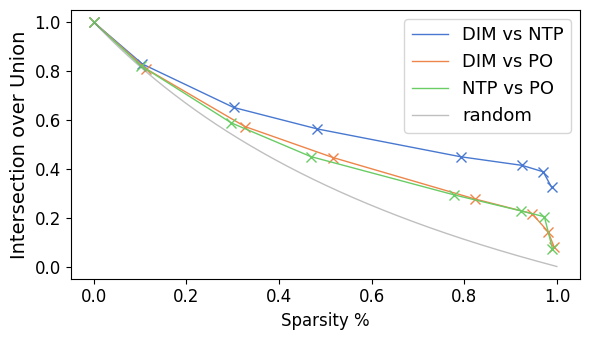

In [38]:

# --- combined plot ---
from matplotlib.lines import Line2D
palette = sns.color_palette("muted", 3)
x_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
y = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

fig, ax_g2 = plt.subplots(figsize=(6, 3.5))

# bottom: IoU 
ax_g2.plot(g2_x_dim_ntp, g2_dim_ntp_ious, color=palette[0], marker='x', markersize=7, linestyle='-', linewidth=1, label='DIM vs NTP')
ax_g2.plot(g2_x_dim_po,  g2_dim_po_ious,  color=palette[1], marker='x', markersize=7, linestyle='-', linewidth=1, label='DIM vs PO')
ax_g2.plot(g2_x_ntp_po,  g2_ntp_po_ious,  color=palette[2], marker='x', markersize=7, linestyle='-', linewidth=1, label='NTP vs PO')
ax_g2.plot(g2_x_random, g2_random_ious, color='gray', linestyle='-', alpha=0.5, linewidth=1, label='random')
ax_g2.set_yticks(y)
ax_g2.set_ylabel('Intersection over Union', fontsize=14)
ax_g2.tick_params(axis='y', labelsize=12)
ax_g2.set_xticks(x_ticks)
ax_g2.set_xticklabels(x_ticks, fontsize=12)
ax_g2.set_xlabel('Sparsity %', fontsize=12)

legend_handles = [
    Line2D([0], [0], color=palette[0], linewidth=1, label='DIM vs NTP'),
    Line2D([0], [0], color=palette[1], linewidth=1, label='DIM vs PO'),
    Line2D([0], [0], color=palette[2], linewidth=1, label='NTP vs PO'),
    Line2D([0], [0], color='gray',     linewidth=1, alpha=0.5, label='random'),
]
ax_g2.legend(handles=legend_handles, fontsize=13, loc='upper right')


plt.tight_layout()
plt.savefig('sparse_iou_g2.pdf', bbox_inches='tight')
plt.show()


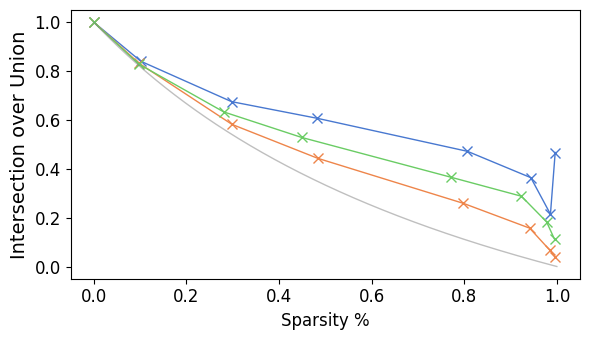

In [40]:
palette = sns.color_palette("muted", 3)
x_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
y = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

fig, ax_g2 = plt.subplots(figsize=(6, 3.5))

# bottom: IoU 
ax_g2.plot(l3_x_dim_ntp, l3_dim_ntp_ious, color=palette[0], marker='x', markersize=7, linestyle='-', linewidth=1, label='DIM vs NTP')
ax_g2.plot(l3_x_dim_po,  l3_dim_po_ious,  color=palette[1], marker='x', markersize=7, linestyle='-', linewidth=1, label='DIM vs PO')
ax_g2.plot(l3_x_ntp_po,  l3_ntp_po_ious,  color=palette[2], marker='x', markersize=7, linestyle='-', linewidth=1, label='NTP vs PO')
ax_g2.plot(l3_x_random, l3_random_ious, color='gray', linestyle='-', alpha=0.5, linewidth=1, label='random')
ax_g2.set_yticks(y)
ax_g2.set_ylabel('Intersection over Union', fontsize=14)
ax_g2.tick_params(axis='y', labelsize=12)
ax_g2.set_xticks(x_ticks)
ax_g2.set_xticklabels(x_ticks, fontsize=12)
ax_g2.set_xlabel('Sparsity %', fontsize=12)

# legend_handles = [
#     Line2D([0], [0], color=palette[0], linewidth=1, label='DIM vs NTP'),
#     Line2D([0], [0], color=palette[1], linewidth=1, label='DIM vs PO'),
#     Line2D([0], [0], color=palette[2], linewidth=1, label='NTP vs PO'),
#     Line2D([0], [0], color='gray',     linewidth=1, alpha=0.5, label='random'),
# ]
# ax_g2.legend(handles=legend_handles, fontsize=13, loc='upper right')


plt.tight_layout()
plt.savefig('sparse_iou_l3.pdf', bbox_inches='tight')
plt.show()
